In [43]:
import sys
from pathlib import Path

from rich import print

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from src.paths import BATHYMETRY

In [31]:
df_read = pd.read_csv(
    BATHYMETRY / "histogram_Aral_Sea_64m_UTM_0.csv",
    sep=";",  # delimiter
    header=0,  # row number for column names
    decimal=",",  # decimal point character
    index_col=None,  # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)

# df_delta = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= -13)].copy()

# df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 11)].copy()

In [32]:
df_read_table = pd.read_csv(
    BATHYMETRY / "Aral_Tabel.csv",
    sep=";",  # delimiter
    header=0,  # row number for column names
    decimal=".",  # decimal point character
    index_col=None,  # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)

In [33]:
df_obs = df_read_table.copy()
df_obs["Elevation"] = df_obs["elevation"]  # -17
# df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 10)].copy(
df_obs.head()

,Year,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity,Elevation
0,1950,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17,52.82
1,1951,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74,52.72
2,1952,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67,52.70
3,1953,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82,52.86
4,1954,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21,53.12


In [34]:
df_c = pd.read_csv(
    BATHYMETRY / "Bathymetry_Creteaux.txt",
    sep="\t",
    decimal=",",
)


df_small = pd.read_csv(
    BATHYMETRY / "ahv_small_aral.csv",
    sep=";",
    decimal=",",
)

df_large = pd.read_csv(
    BATHYMETRY / "ahv_large_aral.csv",
    sep=";",
    decimal=",",
)

print(df_small)

Year  elevation  Area  Volume
0   1986      40.90  2.83   22.47
1   1987      40.80  2.81   22.39
2   1988      40.50  2.75   21.84
3   1989      40.20  2.71   20.28
4   1990      40.50  2.75   21.84
5   1991      40.40  2.73   20.92
6   1992      40.20  2.71   20.28
7   1993      39.37  2.57   18.43
8   1994      40.10  2.69   20.01
9   1995      40.50  2.75   21.84
10  1996      40.50  2.75   21.84
11  1997      41.20  2.91   22.67
12  1998      42.50  3.24   27.03
13  1999      36.80  2.09   12.03
14  2000      39.80  2.62   19.26

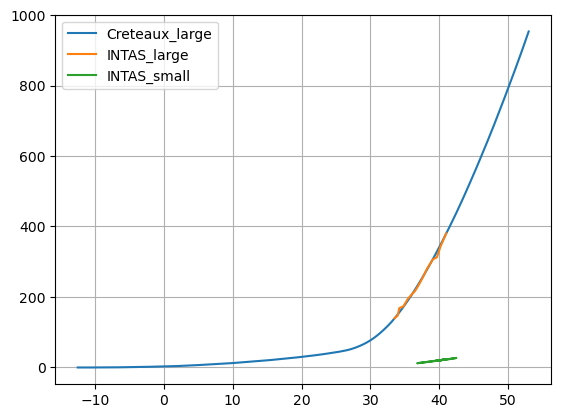

In [45]:
nc_path = BATHYMETRY / "GLOBathy_hAV_relationships.nc"

# Open the NetCDF
ds = xr.open_dataset(nc_path)

In [46]:
ds

<xarray.Dataset> Size: 525MB
Dimensions:          (total_lakes: 1427688, lonlat: 2, z_levels: 11,
                      hAV_coefficients: 3, physical_characteristics: 4)
Dimensions without coordinates: total_lakes, lonlat, z_levels,
                                hAV_coefficients, physical_characteristics
Data variables:
    lake_id          (total_lakes) int64 11MB ...
    lon_lat          (total_lakes, lonlat) float64 23MB ...
    h                (total_lakes, z_levels) float64 126MB ...
    A                (total_lakes, z_levels) float64 126MB ...
    V                (total_lakes, z_levels) float64 126MB ...
    f_hA             (total_lakes, hAV_coefficients) float64 34MB ...
    f_hV             (total_lakes, hAV_coefficients) float64 34MB ...
    lake_attributes  (total_lakes, physical_characteristics) float64 46MB ...

In [47]:
lake13 = ds.where(ds["lake_id"] == 13, drop=True)
lake13

<xarray.Dataset> Size: 368B
Dimensions:          (total_lakes: 1, lonlat: 2, z_levels: 11,
                      hAV_coefficients: 3, physical_characteristics: 4)
Dimensions without coordinates: total_lakes, lonlat, z_levels,
                                hAV_coefficients, physical_characteristics
Data variables:
    lake_id          (total_lakes) float64 8B 13.0
    lon_lat          (total_lakes, lonlat) float64 16B 59.71 44.91
    h                (total_lakes, z_levels) float64 88B 0.0 6.6 ... 59.4 66.0
    A                (total_lakes, z_levels) float64 88B 0.0 218.3 ... 2.38e+04
    V                (total_lakes, z_levels) float64 88B 0.0 0.5431 ... 399.2
    f_hA             (total_lakes, hAV_coefficients) float64 24B 0.1181 ... 0...
    f_hV             (total_lakes, hAV_coefficients) float64 24B 0.0003615 .....
    lake_attributes  (total_lakes, physical_characteristics) float64 32B 66.0...

In [54]:
h = lake13["h"].squeeze().values
A = lake13["A"].squeeze().values
V = lake13["V"].squeeze().values

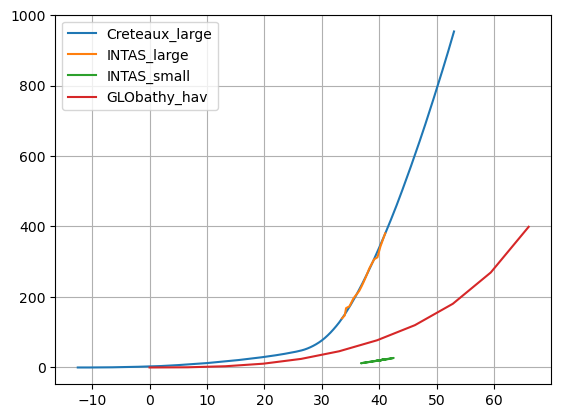

In [56]:
plt.plot(53 - df_c["H"], df_c["v"], label="Creteaux_large")
plt.plot(df_large["elevation"], df_large["Volume"], label="INTAS_large")
plt.plot(df_small["elevation"], df_small["Volume"], label="INTAS_small")
plt.plot(h, V, label="GLObathy_hav")
plt.legend()
plt.grid()